## PARAM

In [1]:
import numpy as np
import pandas as pd
from sklearn import metrics
import tensorflow as tf
from tensorflow.keras import layers
import torch
import math
import pickle
import numpy as np
from sklearn.model_selection import KFold
from tqdm import tqdm 
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from collections import defaultdict
from sklearn import metrics

In [2]:
SEQ_LENGTH = 15 
NUM_FEATURE = 1024 
HIDDEN_DIM = 512          # Adjusted for balance between complexity and generalization
BATCH_SIZE = 32            # Moderate batch size for stable training
NUM_HEADS = 8              # Reverted to original for better feature diversity
NUM_ENCODER_LAYERS = 2     # Reduced to avoid overfitting on positive class
DROPOUT = 0.2
EPOCHS = 20
K_FOLD = 5
NUM_CLASSES = 2
VALIDATION_MODE="independent" # cross or independent

In [3]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/Rag_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Metal_ProtTrans/train_labels.npy", allow_pickle=True)

In [11]:
x_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_CA_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/CA_Train_label.npy", allow_pickle=True)


In [12]:
x_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_CA_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/CA_Test_label.npy", allow_pickle=True)


In [13]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(504142, 1, 15, 1024)
(504142, 2)
(66854, 1, 15, 1024)
(66854, 2)


In [19]:
sum(y_train[:,1]== 1)

8442

In [20]:
sum(y_train[:,0]==1)

495700

In [3]:
# Define the Data Generator
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, data, labels, batch_size):
        self.data = data
        self.labels = labels
        self.batch_size = batch_size
        self.indexes = np.arange(len(self.data))

    def __len__(self):
        return int(np.ceil(len(self.data) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_data = [self.data[i].squeeze() for i in batch_indexes]  # Squeeze to (15, 1024)
        batch_labels = [self.labels[i] for i in batch_indexes]        # Collect labels without flattening
        return np.array(batch_data), np.array(batch_labels)           # Correct shape for both data and labels

## Model Defination code

In [4]:
import tensorflow as tf
from tensorflow.keras import layers

class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, max_len=SEQ_LENGTH, embed_dim=NUM_FEATURE):
        super(PositionalEncoding, self).__init__()
        self.positional_encoding = self.positional_encoding(max_len, embed_dim)

    def positional_encoding(self, max_len, embed_dim):
        pos = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]  # (max_len, 1)
        i = tf.range(embed_dim)[tf.newaxis, :]  # (1, embed_dim)
        angle_rates = 1 / tf.pow(10000.0, (2 * tf.cast(i // 2, tf.float32)) / tf.cast(embed_dim, tf.float32))
        angle_rads = pos * angle_rates  # (max_len, embed_dim)

        # Create sine and cosine encodings
        angle_rads_even = tf.sin(angle_rads[:, 0::2])  # Apply to even indices
        angle_rads_odd = tf.cos(angle_rads[:, 1::2])   # Apply to odd indices

        # Create a new tensor to hold the combined results
        angle_rads_combined = tf.zeros_like(angle_rads)  # Initialize tensor of the same shape
        angle_rads_combined = angle_rads_combined.numpy()  # Convert to NumPy for assignment
        angle_rads_combined[:, 0::2] = angle_rads_even.numpy()  # Assign sine values to even indices
        angle_rads_combined[:, 1::2] = angle_rads_odd.numpy()   # Assign cosine values to odd indices

        return tf.convert_to_tensor(angle_rads_combined, dtype=tf.float32)[tf.newaxis, ...]  # Add batch dimension

    def call(self, inputs):
        return inputs + self.positional_encoding[:, :tf.shape(inputs)[1], :]

class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, num_hidden, num_heads):
        super(SelfAttention, self).__init__()
        self.num_heads = num_heads
        self.attention_head_size = num_hidden // num_heads
        self.all_head_size = num_heads * self.attention_head_size

        self.q_dense = layers.Dense(self.all_head_size)
        self.k_dense = layers.Dense(self.all_head_size)
        self.v_dense = layers.Dense(self.all_head_size)
        self.softmax = layers.Softmax(axis=-1)

    def call(self, q, k, v, mask=None):
        q = self.q_dense(q)
        k = self.k_dense(k)
        v = self.v_dense(v)

        q = tf.reshape(q, (-1, tf.shape(q)[1], self.num_heads, self.attention_head_size))
        k = tf.reshape(k, (-1, tf.shape(k)[1], self.num_heads, self.attention_head_size))
        v = tf.reshape(v, (-1, tf.shape(v)[1], self.num_heads, self.attention_head_size))

        q = tf.transpose(q, perm=[0, 2, 1, 3])
        k = tf.transpose(k, perm=[0, 2, 1, 3])
        v = tf.transpose(v, perm=[0, 2, 1, 3])

        attention_scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(float(self.attention_head_size))
        if mask is not None:
            attention_scores += (mask * -1e9)
        attention_probs = self.softmax(attention_scores)
        context_layer = tf.matmul(attention_probs, v)

        context_layer = tf.transpose(context_layer, perm=[0, 2, 1, 3])
        context_layer = tf.reshape(context_layer, (-1, tf.shape(context_layer)[1], self.all_head_size))
        return context_layer

class PositionalAttention(tf.keras.Model):
    def __init__(self, feature_dim, hidden_dim, num_heads, num_classes, dropout_rate):
        super(PositionalAttention, self).__init__()
        self.positional_encoding = PositionalEncoding(max_len=SEQ_LENGTH, embed_dim=feature_dim)
        self.input_block = tf.keras.Sequential([
            layers.LayerNormalization(epsilon=1e-6),
            layers.Dense(hidden_dim, activation='relu'),
            layers.Dropout(dropout_rate)
        ])
        self.attention = SelfAttention(hidden_dim, num_heads)
        self.feed_forward = tf.keras.Sequential([
            layers.Dense(hidden_dim, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(hidden_dim, activation='relu')
        ])
        self.pooling = layers.GlobalAveragePooling1D()
        self.output_layer = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, mask=None):
        if len(inputs.shape) != 3:
            raise ValueError(f"Expected input to have shape (batch_size, seq_length, num_features), but got {inputs.shape}.")
        
        # Apply positional encoding
        x = self.positional_encoding(inputs)
        x = self.input_block(x)
        x = self.attention(x, x, x, mask)
        x = self.feed_forward(x)
        x = self.pooling(x)
        output = self.output_layer(x)
        return output

In [5]:
# Utility functions
def load_protein_ids(path):
    with open(path, "r") as f:
        return [line.strip() for line in f if line.strip()]

def load_protein_lengths(label_folder, protein_ids):
    lengths = {}
    for pid in protein_ids:
        label_path = os.path.join(label_folder, f"{pid}.fasta")
        with open(label_path, "r") as f:
            f.readline()              # skip header
            label_str = f.readline().strip()
        lengths[pid] = len(label_str)
    return lengths
    
def build_protein_ranges(protein_ids, protein_lengths):
    ranges = {}
    start = 0
    for pid in protein_ids:
        end = start + protein_lengths[pid]
        ranges[pid] = (start, end)  # [start, end)
        start = end
    return ranges


In [10]:
# Function to save ROC values
def SAVEROC(fpr, tpr, auc, model_name):
    roc_data = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    file_path = f"C:/jupyter/Malik/Metal Binding/Code/Additional Test/ROC/REVISE/{model_name}.pkl"
    with open(file_path, 'wb') as f:
        pickle.dump(roc_data, f)
    print(f"ROC values saved to {file_path}")

# def model_test(model, x_test, y_test, model_name):
#     print(f'Test data shape: {x_test.shape}')
    
#     # Get model predictions and select the positive class probabilities
#     pred_test = model.predict(x_test)[:, 1]  # Use the positive class probabilities for binary ROC

#     # Compute ROC curve and AUC for binary classification
#     fpr, tpr, thresholds = metrics.roc_curve(y_test[:, 1], pred_test)  # y_test[:, 1] gives true positive labels
#     AUC = metrics.auc(fpr, tpr)
    
#     # Display ROC curve
#     display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name=' PositionalAttentionModel')
#     display.plot()
    
#     # Save ROC values
#     SAVEROC(fpr, tpr, AUC, model_name)
    
#     # Calculate G-Mean to find the optimal threshold
#     gmeans = np.sqrt(tpr * (1 - fpr))
#     ix = np.argmax(gmeans)
#     best_threshold = thresholds[ix]
#     print(f'Best Threshold={best_threshold}, G-Mean={gmeans[ix]}')
    
#     # Apply threshold to get binary predictions
#     y_pred = (pred_test >= best_threshold).astype(int)
    
#     # Compute confusion matrix and metrics
#     TN, FP, FN, TP = metrics.confusion_matrix(y_test[:, 1], y_pred).ravel()  # y_test[:, 1] for true positive class
#     Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
#     Spec = TN / (FP + TN) if (FP + TN) > 0 else 0.0
#     Acc = (TP + TN) / (TP + FP + TN + FN)
#     Precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
#     MCC = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
#           if (TP + FP > 0 and TP + FN > 0 and TN + FP > 0 and TN + FN > 0) else 0.0
#     F1 = 2 * Precision * Sens / (Precision + Sens) if (Precision + Sens) > 0 else 0.0

#     # Print results
#     print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sensitivity={Sens:.4f}, '
#           f'Specificity={Spec:.4f}, Accuracy={Acc:.4f}, Precision={Precision:.4f}, '
#           f'F1={F1:.4f}, MCC={MCC:.4f}, AUC={AUC:.4f}\n')

#     return TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Precision

def model_test(model, x_test, y_test, protein_ranges, model_name):
    print(f'Test data shape: {x_test.shape}')

    pred_test = model.predict(x_test)[:, 1]

    # ROC
    fpr, tpr, thresholds = metrics.roc_curve(y_test[:, 1], pred_test)
    AUC = metrics.auc(fpr, tpr)

    # Display ROC curve
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name=' PositionalAttentionModel')
    display.plot()
    
    # Save ROC values
    SAVEROC(fpr, tpr, AUC, model_name)

    gmeans = np.sqrt(tpr * (1 - fpr))
    ix = np.argmax(gmeans)
    best_threshold = thresholds[ix]
    # valid = np.isfinite(thresholds)
    # ix = np.argmax(gmeans[valid])
    # best_threshold = thresholds[valid][ix]
    print(f'Best Threshold={best_threshold}, G-Mean={gmeans[ix]}')

    y_true = y_test[:, 1]
    y_pred = (pred_test >= 0.05).astype(int)

    # Global confusion matrix
    TN, FP, FN, TP = metrics.confusion_matrix(y_true, y_pred).ravel()
    Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    Spec = TN / (FP + TN) if (FP + TN) > 0 else 0.0
    Acc = (TP + TN) / (TP + FP + TN + FN)
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    MCC = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
          if (TP + FP > 0 and TP + FN > 0 and TN + FP > 0 and TN + FN > 0) else 0.0
    F1 = 2 * Precision * Sens / (Precision + Sens) if (Precision + Sens) > 0 else 0.0

    # Print results
    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sensitivity={Sens:.4f}, '
          f'Specificity={Spec:.4f}, Accuracy={Acc:.4f}, Precision={Precision:.4f}, '
          f'F1={F1:.4f}, MCC={MCC:.4f}, AUC={AUC:.4f}\n')

    # ----------------------------
    # FP PER PROTEIN (CORRECT WAY)
    # ----------------------------
    fp_per_protein = {}

    for pid, (start, end) in protein_ranges.items():
        y_true_p = y_true[start:end]
        y_pred_p = y_pred[start:end]

        fp_count = np.sum((y_true_p == 0) & (y_pred_p == 1))
        fp_per_protein[pid] = int(fp_count)

    avg_fp_per_protein = np.mean(list(fp_per_protein.values()))

    print(f"Average number of FPs per protein: {avg_fp_per_protein:.4f}")

    # Save results
    with open(f"{model_name}_FP_per_protein.txt", "w") as f:
        for pid in sorted(fp_per_protein):
            f.write(f"{pid}\t{fp_per_protein[pid]}\n")
        f.write(f"\nAverage_FP_per_protein\t{avg_fp_per_protein:.4f}\n")

    return TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Precision, avg_fp_per_protein


In [6]:
# Function to save ROC values
def SAVEROC(fpr, tpr, auc, model_name):
    roc_data = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    file_path = f"C:/jupyter/Malik/Metal Binding/Code/Additional Test/ROC/REVISE/{model_name}.pkl"
    with open(file_path, 'wb') as f:
        pickle.dump(roc_data, f)
    print(f"ROC values saved to {file_path}")
    
def model_test(model, x_test, y_test, protein_ranges, data_folder, model_name):
    print(f'Test data shape: {x_test.shape}')

    pred_test = model.predict(x_test)[:, 1]   # probabilities for positive class

    # ROC and best threshold (your existing code)
    fpr, tpr, thresholds = metrics.roc_curve(y_test[:, 1], pred_test)
    AUC = metrics.auc(fpr, tpr)

    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name='PositionalAttentionModel')
    display.plot()
    
    SAVEROC(fpr, tpr, AUC, model_name)

    gmeans = np.sqrt(tpr * (1 - fpr))
    valid = np.isfinite(thresholds)
    ix = np.argmax(gmeans[valid])
    best_threshold = thresholds[valid][ix]
    print(f'Best Threshold={best_threshold:.6f}, G-Mean={gmeans[ix]:.4f}')

    y_true = y_test[:, 1]
    y_pred = (pred_test >= best_threshold).astype(int)

    # Global confusion matrix (your existing code)
    TN, FP, FN, TP = metrics.confusion_matrix(y_true, y_pred).ravel()
    Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    Spec = TN / (FP + TN) if (FP + TN) > 0 else 0.0
    Acc = (TP + TN) / (TP + FP + TN + FN)
    Precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    MCC = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
          if (TP + FP > 0 and TP + FN > 0 and TN + FP > 0 and TN + FN > 0) else 0.0
    F1 = 2 * Precision * Sens / (Precision + Sens) if (Precision + Sens) > 0 else 0.0

    print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sensitivity={Sens:.4f}, '
          f'Specificity={Spec:.4f}, Accuracy={Acc:.4f}, Precision={Precision:.4f}, '
          f'F1={F1:.4f}, MCC={MCC:.4f}, AUC={AUC:.4f}\n')

    # FP per protein (your existing code)
    fp_per_protein = {}
    for pid, (start, end) in protein_ranges.items():
        y_true_p = y_true[start:end]
        y_pred_p = y_pred[start:end]
        fp_count = np.sum((y_true_p == 0) & (y_pred_p == 1))
        fp_per_protein[pid] = int(fp_count)

    avg_fp_per_protein = np.mean(list(fp_per_protein.values()))
    print(f"Average number of FPs per protein: {avg_fp_per_protein:.4f}")

    # ────────────────────────────────────────────────────────────────
    # NEW: Per-protein detailed CSV with indices and sequence
    # ────────────────────────────────────────────────────────────────
    csv_rows = []

    # We need sequences → load them from the same fasta files used for lengths
    # data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MG/Sequence/Test"  # adjust if needed

    for pid, (global_start, global_end) in protein_ranges.items():
        # Load sequence
        fasta_path = os.path.join(data_folder, f"{pid}.fasta")
        with open(fasta_path, "r") as f:
            header = f.readline().strip()  # >ID ...
            sequence = f.readline().strip()

        # Local slice for this protein
        local_true = y_true[global_start:global_end]
        local_pred = y_pred[global_start:global_end]
        local_prob = pred_test[global_start:global_end]

        # Indices (0-based within this protein)
        tp_idx = np.where((local_true == 1) & (local_pred == 1))[0].tolist()
        fp_idx = np.where((local_true == 0) & (local_pred == 1))[0].tolist()
        tn_idx = np.where((local_true == 0) & (local_pred == 0))[0].tolist()
        fn_idx = np.where((local_true == 1) & (local_pred == 0))[0].tolist()

        # Convert lists to string representation (e.g. "[3, 15, 27]")
        def list_to_str(lst):
            if not lst:
                return "[]"
            return "[" + ", ".join(map(str, lst)) + "]"

        csv_rows.append({
            "ID": pid,
            "sequence": sequence,
            "TP": list_to_str(tp_idx),
            "FP": list_to_str(fp_idx),
            "TN": list_to_str(tn_idx),
            "FN": list_to_str(fn_idx),
            "prob": ",".join(f"{p:.6f}" for p in local_prob),   # comma-separated probs
            "pred": ",".join(map(str, local_pred))               # comma-separated 0/1
        })

    # Save to CSV
    csv_df = pd.DataFrame(csv_rows)
    output_csv = f"{model_name}_per_protein_predictions.csv"
    csv_df.to_csv(output_csv, index=False)
    print(f"Per-protein detailed results saved to: {output_csv}")

    # Also keep your existing per-protein FP txt file
    with open(f"{model_name}_FP_per_protein.txt", "w") as f:
        for pid in sorted(fp_per_protein):
            f.write(f"{pid}\t{fp_per_protein[pid]}\n")
        f.write(f"\nAverage_FP_per_protein\t{avg_fp_per_protein:.4f}\n")

    return TP, FP, TN, FN, Sens, Spec, Acc, MCC, AUC, F1, Precision, avg_fp_per_protein

## Independent Test Set with CA

Shape of y_train: (504142, 2)
Model: "positional_attention_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_3 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_6 (Sequential)   (32, 15, 512)             526848    
                                                                 
 self_attention_3 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_7 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_3   multiple                 0         
 (GlobalAveragePooling1D)                                        
              

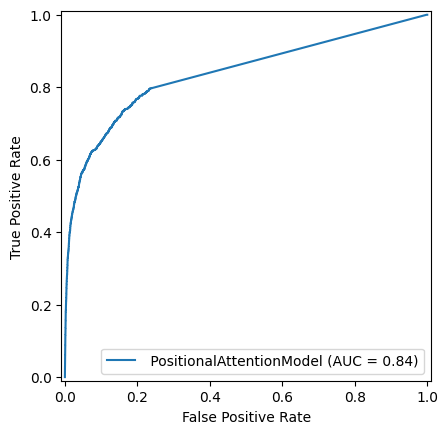

In [24]:
# Training code
import os
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train.flatten() if y_train.ndim > 1 else y_train)
class_weight_dict = dict(zip(classes, class_weights))

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "CA_metal"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/CA_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/CA/Label/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges, model_name)
    

Shape of y_train: (504142, 2)
Model: "positional_attention_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_2 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_4 (Sequential)   (32, 15, 512)             526848    
                                                                 
 self_attention_2 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_5 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_2   multiple                 0         
 (GlobalAveragePooling1D)                                        
              

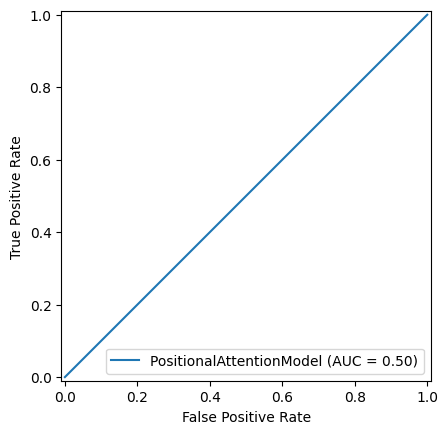

In [14]:
# Training code
import os
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train.flatten() if y_train.ndim > 1 else y_train)
class_weight_dict = dict(zip(classes, class_weights))

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)
    # history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "CA_metal"
    data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/CA/Sequence/Test"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/CA_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/CA/Label/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges,data_folder, model_name)
    

In [13]:
print(f'Test data shape: {x_test_reshaped.shape}')

# Get model predictions and select the positive class probabilities
pred_test = model.predict(x_test_reshaped)[:, 1]  # Use the positive class probabilities for binary ROC

# Compute ROC curve and AUC for binary classification
fpr, tpr, thresholds = metrics.roc_curve(y_test[:, 1], pred_test)  # y_test[:, 1] gives true positive labels
AUC = metrics.auc(fpr, tpr)

# Display ROC curve
# display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=AUC, estimator_name=' PositionalAttentionModel')
# display.plot()

# Save ROC values
# SAVEROC(fpr, tpr, AUC, model_name)

# Calculate G-Mean to find the optimal threshold
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
best_threshold = thresholds[ix]
print(f'Best Threshold={best_threshold}, G-Mean={gmeans[ix]}')

# Apply threshold to get binary predictions
# y_pred = (pred_test >= best_threshold).astype(int)
y_pred = (pred_test >= 0.07).astype(int)

# Compute confusion matrix and metrics
TN, FP, FN, TP = metrics.confusion_matrix(y_test[:, 1], y_pred).ravel()  # y_test[:, 1] for true positive class
Sens = TP / (TP + FN) if (TP + FN) > 0 else 0.0
Spec = TN / (FP + TN) if (FP + TN) > 0 else 0.0
Acc = (TP + TN) / (TP + FP + TN + FN)
Precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
MCC = ((TP * TN) - (FP * FN)) / math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) \
      if (TP + FP > 0 and TP + FN > 0 and TN + FP > 0 and TN + FN > 0) else 0.0
F1 = 2 * Precision * Sens / (Precision + Sens) if (Precision + Sens) > 0 else 0.0

# Print results
print(f'TP={TP}, FP={FP}, TN={TN}, FN={FN}, Sensitivity={Sens:.4f}, '
      f'Specificity={Spec:.4f}, Accuracy={Acc:.4f}, Precision={Precision:.4f}, '
      f'F1={F1:.4f}, MCC={MCC:.4f}, AUC={AUC:.4f}\n')

Test data shape: (66854, 15, 1024)
2090/2090 [==============================] - 3s 2ms/step
Best Threshold=0.03012417070567608, G-Mean=0.7181565090471979
TP=412, FP=3604, TN=62216, FN=622, Sensitivity=0.3985, Specificity=0.9452, Accuracy=0.9368, Precision=0.1026, F1=0.1632, MCC=0.1785, AUC=0.8003



## Independent Test Set With MG

In [7]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_MG_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MG_Train_label.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_MG_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MG_Test_label.npy", allow_pickle=True)

In [8]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(575893, 1, 15, 1024)
(575893, 2)
(88806, 1, 15, 1024)
(88806, 2)


Class weights: {0: 0.5055489033871047, 1: 45.553947160259455}
Shape of y_train: (575893, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d (G  multiple                 0         
 lobalAveragePooling

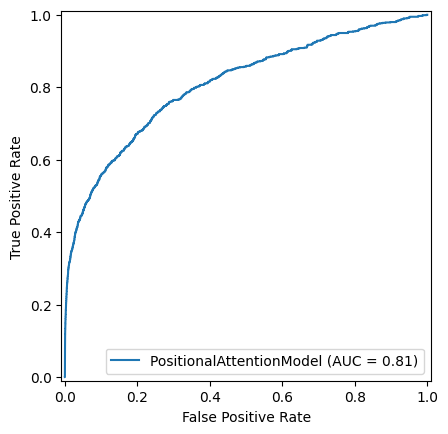

In [9]:
# Training code
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
EPOCHS = 5

# Assuming positive is class 1 (second column)
y_train_flat = np.argmax(y_train, axis=1)   # 0 or 1
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)
    # history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "MG_metal"
    data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MG/Sequence/Test"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MG_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MG/Label/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges,data_folder, model_name)
    

Class weights: {0: 0.5055489033871047, 1: 45.553947160259455}
Shape of y_train: (575893, 2)
Model: "positional_attention_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_1 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_2 (Sequential)   (32, 15, 512)             526848    
                                                                 
 self_attention_1 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_3 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_1   multiple                 0         
 (GlobalAveragePoo

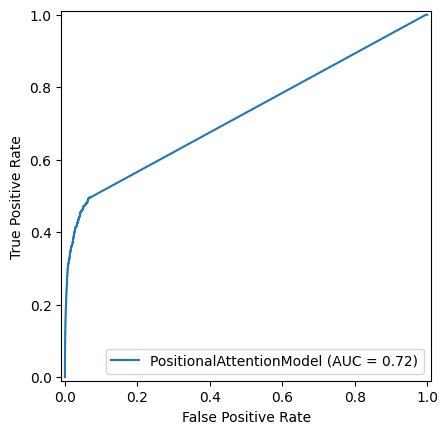

In [10]:
# Training code
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
EPOCHS = 20

# Assuming positive is class 1 (second column)
y_train_flat = np.argmax(y_train, axis=1)   # 0 or 1
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)
    # history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "MG_metal"
    data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MG/Sequence/Test"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MG_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MG/Label/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges,data_folder, model_name)
    

## Independent Test Set With MN

In [7]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_MN_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MN_Train_label.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_MN_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MN_Test_label.npy", allow_pickle=True)

In [8]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(181699, 1, 15, 1024)
(181699, 2)
(20419, 1, 15, 1024)
(20419, 2)


Shape of y_train: (181699, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d (G  multiple                 0         
 lobalAveragePooling1D)                                          
                

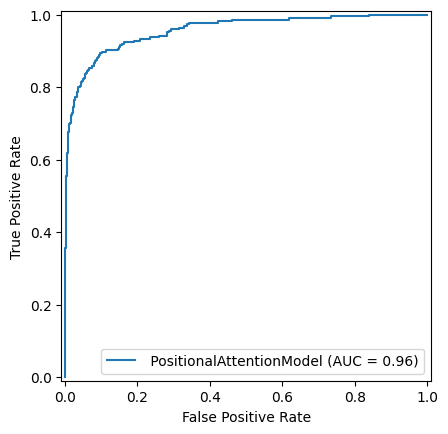

In [13]:
# Training code
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_MN" 
    model_test(model, x_test_reshaped, y_test, model_name)

Class weights: {0: 0.5071339656028983, 1: 35.543622848200314}
Shape of y_train: (181699, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d (G  multiple                 0         
 lobalAveragePooling

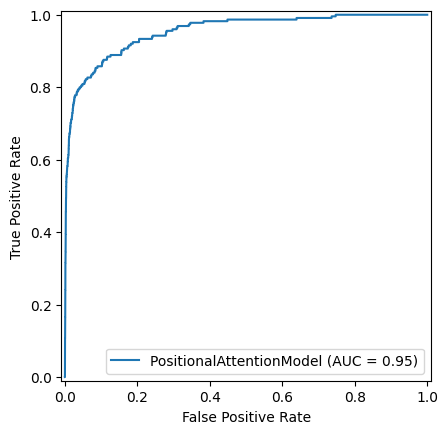

In [9]:
# Training code
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# Assuming positive is class 1 (second column)
y_train_flat = np.argmax(y_train, axis=1)   # 0 or 1
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)
    # history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "MN_metal"
    data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MN/Sequence/Test"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/MN_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/MN/Labels/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges,data_folder, model_name)
    

## Independent Test Set With ZN

In [10]:
import numpy as np
x_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_ZN_train_data_N.npy", allow_pickle=True)
y_train = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/ZN_Train_label.npy", allow_pickle=True)
x_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/RAG_Class/Rag_ZN_test_data_N.npy", allow_pickle=True)
y_test = np.load("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/ZN_Test_label.npy", allow_pickle=True)

In [11]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test .shape)

(474915, 1, 15, 1024)
(474915, 2)
(56020, 1, 15, 1024)
(56020, 2)


Shape of y_train: (474915, 2)
Model: "positional_attention"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding (Positi  multiple                 0         
 onalEncoding)                                                   
                                                                 
 sequential (Sequential)     (32, 15, 512)             526848    
                                                                 
 self_attention (SelfAttenti  multiple                 787968    
 on)                                                             
                                                                 
 sequential_1 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d (G  multiple                 0         
 lobalAveragePooling1D)                                          
                

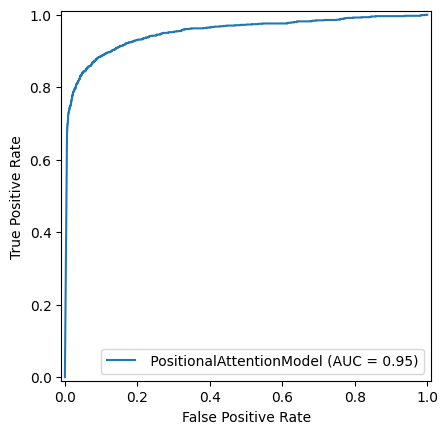

In [8]:
# Training code
if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "PATN_ZN" 
    model_test(model, x_test_reshaped, y_test, model_name)

Class weights: {0: 0.5082740419192439, 1: 30.714978657353512}
Shape of y_train: (474915, 2)
Model: "positional_attention_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 positional_encoding_1 (Posi  multiple                 0         
 tionalEncoding)                                                 
                                                                 
 sequential_2 (Sequential)   (32, 15, 512)             526848    
                                                                 
 self_attention_1 (SelfAtten  multiple                 787968    
 tion)                                                           
                                                                 
 sequential_3 (Sequential)   (32, 15, 512)             525312    
                                                                 
 global_average_pooling1d_1   multiple                 0         
 (GlobalAveragePoo

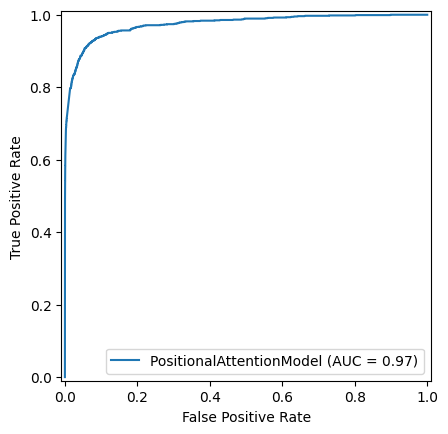

In [12]:
# Training code
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os

# Assuming positive is class 1 (second column)
y_train_flat = np.argmax(y_train, axis=1)   # 0 or 1
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_flat),
    y=y_train_flat
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print("Class weights:", class_weight_dict)

if VALIDATION_MODE == "independent":
    # Check the shape of y_train
    print("Shape of y_train:", y_train.shape)

    # Initialize the data generator with the batch size
    generator = DataGenerator(x_train, y_train, batch_size=BATCH_SIZE)

    # Instantiate the AttentionOnlyModel
    model = PositionalAttention(
        feature_dim=NUM_FEATURE,     # Input feature dimension (1024)
        hidden_dim=HIDDEN_DIM,       # Hidden dimension for model
        num_heads=NUM_HEADS,         # Number of attention heads
        num_classes=NUM_CLASSES,     # Number of output classes (2)
        dropout_rate=DROPOUT         # Dropout rate
    )

    # Compile the model with categorical_crossentropy for one-hot encoded labels
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Build the model with the input shape expected by the DataGenerator
    model.build(input_shape=(BATCH_SIZE, SEQ_LENGTH, NUM_FEATURE))
    
    model.summary()

    # Train the model
    history = model.fit(generator, epochs=EPOCHS, verbose=1)
    # history = model.fit(generator, epochs=EPOCHS,class_weight=class_weight_dict, verbose=1)

# Test the model
if VALIDATION_MODE == "independent":
    x_test_reshaped = x_test.reshape(-1, 15, 1024)  # Adjust this shape as needed
    print(f"Reshaped Test data shape: {x_test_reshaped.shape}")
    # Run the model test function directly with one-hot encoded y_test
    model_name = "ZN_metal"
    data_folder = "C:/jupyter/Malik/Metal Binding/AdditionalTestSet/ZN/Sequences/Test"
    #NEW CALCULATION
    protein_ids = load_protein_ids("C:/jupyter/Malik/Metal Binding/Additional_ProtTrans/ZN_Test_filenames.txt")
    protein_lengths = load_protein_lengths("C:/jupyter/Malik/Metal Binding/AdditionalTestSet/ZN/Labels/Test", protein_ids)
    protein_ranges = build_protein_ranges(protein_ids, protein_lengths)

    model_test(model, x_test_reshaped, y_test,protein_ranges,data_folder, model_name)
    

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))


True
NVIDIA GeForce RTX 4060 Ti
